 # Whisper Accent Robustness — Model Performance Evaluation



 Run `eval_model_perf.py` on SLURM first to generate the CSVs this notebook reads.



 - **Scripted**     → 6 held-out test speakers (never seen during training)

 - **Spontaneous**  → suitcase corpus (OOD, all speakers)



 Metrics:

 - **WER**  — word error rate (primary ASR metric)

 - **PER**  — phoneme error rate via G2P; labelled "PER (G2P)" throughout

In [14]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = "results/model_perf_comparison"

# Keys must match {model_key} in CSV filenames; values are display labels
MODEL_KEYS = {
    "baseline":      "Zero-shot",
    # "baseline_lora": "Naive LoRA FT",
    "no_aux":        "Naive LoRA FT",
    # "no_aux_heldout_chinese":        "Naive LoRA FT (heldout Chinese)",
    # "ctc_aux_l3":    "CTC Aux",
    # "feat_aux":      "Feat Aux",
    # "feat_aux_heldout_chinese":      "Feat Aux (heldout Chinese)",
    "feat_aux0p3":      "Feat Aux (0.3)",
    # "both_aux":      "CTC + Feat",

    "whisfusion_zs": "WhisFusion (Zero-shot)",
}
SPLITS = ["scripted", "spontaneous"]


In [15]:
# ── Imports ───────────────────────────────────────────────────────────────────
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from jiwer import wer as jiwer_wer

pd.set_option("display.max_colwidth", 80)


In [16]:
def load_results(model_key: str, split: str) -> pd.DataFrame | None:
    p = Path(RESULTS_DIR) / f"{model_key}_{split}_predictions.csv"
    if not p.exists():
        print(f"  [missing] {p} — run eval_model_perf.py first")
        return None
    return pd.read_csv(p)

# ── Load all cached CSVs ──────────────────────────────────────────────────────
results: dict[str, dict[str, pd.DataFrame | None]] = {}
for key in MODEL_KEYS:
    results[key] = {}
    for split in SPLITS:
        df = load_results(key, split)
        results[key][split] = df
        if df is not None:
            print(f"  loaded  {key}/{split}: {len(df):,} rows")


  loaded  baseline/scripted: 7,638 rows
  loaded  baseline/spontaneous: 441 rows
  loaded  no_aux/scripted: 7,638 rows
  loaded  no_aux/spontaneous: 441 rows
  loaded  feat_aux0p3/scripted: 7,638 rows
  loaded  feat_aux0p3/spontaneous: 441 rows
  loaded  whisfusion_zs/scripted: 7,638 rows
  [missing] results/model_perf_comparison/whisfusion_zs_spontaneous_predictions.csv — run eval_model_perf.py first


In [17]:
# ── Helpers ──────────────────────────────────────────────────────────────────


def available(key: str, split: str) -> bool:
    return results.get(key, {}).get(split) is not None


def corpus_wer(df: pd.DataFrame) -> float:
    return float(jiwer_wer(
        df["reference_norm"].fillna("").tolist(),
        df["prediction_norm"].fillna("").tolist(),
    ))


def corpus_per(df: pd.DataFrame) -> float | None:
    """Mean utterance PER (G2P-derived), precomputed by eval_model_perf.py."""
    if "utt_per" not in df.columns:
        return None
    vals = df["utt_per"].dropna()
    return float(vals.mean()) if len(vals) else None


def grouped_wer(df: pd.DataFrame, group_col: str = "l1") -> pd.DataFrame:
    rows = []
    for grp, sub in df.groupby(group_col):
        rows.append({
            group_col:  grp,
            "num_utts": len(sub),
            "wer":      float(jiwer_wer(
                            sub["reference_norm"].fillna("").tolist(),
                            sub["prediction_norm"].fillna("").tolist(),
                        )),
            "per":      float(sub["utt_per"].dropna().mean())
                        if "utt_per" in sub.columns else None,
        })
    return pd.DataFrame(rows)


print("Helpers loaded.")


Helpers loaded.


 ---

 # Part 1 — Overall WER & PER (G2P)

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for key, label in MODEL_KEYS.items():
    for split in SPLITS:
        if not available(key, split):
            continue
        df  = results[key][split]
        wer = corpus_wer(df)
        per = corpus_per(df)
        rows.append({"Model": label, "Split": split, "WER": wer, "PER (G2P)": per})

overall_df = pd.DataFrame(rows)

for metric in ["WER", "PER (G2P)"]:
    pivot = overall_df.pivot(index="Model", columns="Split", values=metric)
    display(
        pivot.style
             .format("{:.4f}")
             .background_gradient(cmap="RdYlGn_r", axis=0)
             .set_caption(f"{metric} by Model × Split (lower is better)")
    )


Split,scripted,spontaneous
Model,,
Feat Aux (0.3),0.0759,0.2633
Naive LoRA FT,0.0731,0.2579
WhisFusion (Zero-shot),0.2678,nan
Zero-shot,0.1625,0.1979


Split,scripted,spontaneous
Model,,
Feat Aux (0.3),0.0497,0.2668
Naive LoRA FT,0.0452,0.2686
WhisFusion (Zero-shot),0.1524,nan
Zero-shot,0.0871,0.1892


In [19]:
from plotly.subplots import make_subplots

# ── Separate WER/PER into side-by-side subplots, one figure per split ─────────

for split in SPLITS:
    sub = overall_df[overall_df["Split"] == split].copy()
    if sub.empty:
        continue

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("WER", "PER (G2P)"),
        shared_yaxes=True,
    )

    # Left: WER
    wer_vals = sub["WER"]
    fig.add_trace(
        go.Bar(
            name="WER",
            x=sub["Model"].tolist(),
            y=wer_vals.tolist(),
            text=[f"{v:.1%}" if pd.notna(v) else "" for v in wer_vals],
            textposition="outside",
            showlegend=False,
        ),
        row=1, col=1
    )

    # Right: PER
    per_vals = sub["PER (G2P)"]
    if per_vals.notna().any():
        fig.add_trace(
            go.Bar(
                name="PER (G2P)",
                x=sub["Model"].tolist(),
                y=per_vals.tolist(),
                text=[f"{v:.1%}" if pd.notna(v) else "" for v in per_vals],
                textposition="outside",
                showlegend=False,
            ),
            row=1, col=2
        )

    fig.update_yaxes(title_text="Error Rate", tickformat=".0%", row=1, col=1)
    fig.update_yaxes(tickformat=".0%", row=1, col=2)
    fig.update_layout(
        title=f"WER vs PER by Model — {split.capitalize()}",
        margin=dict(t=90),
    )
    fig.show()


 ---

 # Part 2 — Per-L1 WER

In [20]:
for split in SPLITS:
    l1_rows = []
    for key, label in MODEL_KEYS.items():
        if not available(key, split):
            continue
        grp = grouped_wer(results[key][split], "l1")
        grp["Model"] = label
        l1_rows.append(grp)
    if not l1_rows:
        continue

    l1_df = pd.concat(l1_rows, ignore_index=True)

    # Delta vs zero-shot baseline (negative = improvement)
    base_label = MODEL_KEYS["no_aux"]
    base_wer   = (
        l1_df[l1_df["Model"] == base_label][["l1", "wer"]]
        .rename(columns={"wer": "wer_base"})
    )
    l1_df = l1_df.merge(base_wer, on="l1", how="left")
    l1_df["wer_delta_pct"] = (
        (l1_df["wer"] - l1_df["wer_base"]) / l1_df["wer_base"] * 100
    )

    l1s = sorted(l1_df["l1"].unique())

    fig = go.Figure()
    for key, label in MODEL_KEYS.items():
        sub = l1_df[l1_df["Model"] == label].set_index("l1")
        fig.add_trace(go.Bar(
            name = label,
            x    = l1s,
            y    = [sub.loc[l, "wer"] if l in sub.index else None for l in l1s],
            text = [f"{sub.loc[l, 'wer']:.1%}" if l in sub.index else "" for l in l1s],
            textposition = "outside",
        ))
    fig.update_layout(
        title   = f"WER by L1 — {split.capitalize()}",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
        margin  = dict(t=80),
    )
    fig.show()

    out = Path(RESULTS_DIR) / f"comparison_{split}_by_l1.csv"
    l1_df.to_csv(out, index=False)
    print(f"Saved {out}")
    display(
        l1_df.sort_values(["l1", "Model"])
             .style.format({
                 "wer":           "{:.4f}",
                 "wer_base":      "{:.4f}",
                 "wer_delta_pct": "{:+.1f}%",
                 "per":           lambda v: f"{v:.4f}" if pd.notna(v) else "—",
             })
             .set_caption(f"{split.capitalize()} — Per-L1 WER")
    )


Saved results/model_perf_comparison/comparison_scripted_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
14,Arabic,974,0.1546,0.1230,Feat Aux (0.3),0.1084,+42.6%
7,Arabic,974,0.1084,0.0718,Naive LoRA FT,0.1084,+0.0%
21,Arabic,974,0.3701,0.2205,WhisFusion (Zero-shot),0.1084,+241.6%
0,Arabic,974,0.2388,0.1375,Zero-shot,0.1084,+120.4%
15,Chinese,1130,0.0895,0.0543,Feat Aux (0.3),0.0910,-1.6%
8,Chinese,1130,0.0910,0.0543,Naive LoRA FT,0.0910,+0.0%
22,Chinese,1130,0.3141,0.1823,WhisFusion (Zero-shot),0.0910,+245.0%
1,Chinese,1130,0.1916,0.1060,Zero-shot,0.0910,+110.4%
16,English,1132,0.0187,0.0066,Feat Aux (0.3),0.0198,-5.6%
9,English,1132,0.0198,0.0072,Naive LoRA FT,0.0198,+0.0%


Saved results/model_perf_comparison/comparison_spontaneous_by_l1.csv


,l1,num_utts,wer,per,Model,wer_base,wer_delta_pct
16,Arabic,3,0.1347,0.0744,Feat Aux (0.3),0.1554,-13.3%
8,Arabic,3,0.1554,0.0885,Naive LoRA FT,0.1554,+0.0%
0,Arabic,3,0.1192,0.0663,Zero-shot,0.1554,-23.3%
17,Chinese,4,0.2318,0.1185,Feat Aux (0.3),0.2190,+5.8%
9,Chinese,4,0.2190,0.1135,Naive LoRA FT,0.2190,+0.0%
1,Chinese,4,0.2135,0.1153,Zero-shot,0.2190,-2.5%
18,English,184,0.3189,0.2910,Feat Aux (0.3),0.1972,+61.7%
10,English,184,0.1972,0.1853,Naive LoRA FT,0.1972,+0.0%
2,English,184,0.1688,0.1469,Zero-shot,0.1972,-14.4%
19,Hindi,3,0.1349,0.0628,Feat Aux (0.3),0.1026,+31.4%


 ---

 # Part 3 — Scripted vs Spontaneous Gap (zero-shot)



 Different corpora → compared at L1 level, not speaker level.

In [21]:
if available("baseline", "scripted") and available("baseline", "spontaneous"):
    s_g  = grouped_wer(results["baseline"]["scripted"],    "l1").rename(columns={"wer": "WER_scripted"})
    sp_g = grouped_wer(results["baseline"]["spontaneous"], "l1").rename(columns={"wer": "WER_spontaneous"})
    gap  = s_g[["l1", "WER_scripted"]].merge(
               sp_g[["l1", "WER_spontaneous"]], on="l1", how="inner")
    gap["gap"] = gap["WER_spontaneous"] - gap["WER_scripted"]

    l1s = gap["l1"].tolist()
    fig = go.Figure()
    fig.add_trace(go.Bar(name="Scripted",    x=l1s, y=gap["WER_scripted"].tolist()))
    fig.add_trace(go.Bar(name="Spontaneous", x=l1s, y=gap["WER_spontaneous"].tolist()))
    fig.update_layout(
        title   = "Zero-shot WER — Scripted vs Spontaneous by L1",
        barmode = "group",
        yaxis   = dict(title="WER", tickformat=".0%"),
        legend  = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
    )
    fig.show()
    display(
        gap.style
           .format({c: "{:.4f}" for c in ["WER_scripted", "WER_spontaneous", "gap"]})
           .set_caption("Scripted vs Spontaneous WER gap (zero-shot)")
    )


,l1,WER_scripted,WER_spontaneous,gap
0,Arabic,0.2388,0.1192,-0.1196
1,Chinese,0.1916,0.2135,0.0219
2,English,0.0382,0.1688,0.1307
3,Hindi,0.0653,0.1026,0.0373
4,Korean,0.0805,0.1553,0.0748
5,Spanish,0.2284,0.0967,-0.1317
6,Vietnamese,0.3117,0.2287,-0.0830


 ---

 # Part 4 — Utterance-level Analysis

In [23]:
# ── UTT WER distributions ─────────────────────────────────────────────────────
fig = go.Figure()
key = "no_aux"
label = MODEL_KEYS[key]
split = "scripted"
fig.add_trace(go.Histogram(
    x       = results[key][split]["utt_wer"],
    name    = f"{label} / {split}",
    opacity = 0.5,
    nbinsx  = 40,
))
fig.update_layout(
    title    = "Utterance WER Distribution — All Conditions",
    barmode  = "overlay",
    xaxis    = dict(title="Utterance WER"),
    yaxis    = dict(title="Count"),
    legend   = dict(orientation="h", y=1.12, xanchor="center", x=0.5),
)
fig.show()


In [26]:
# ── Worst utterances per model — scripted, cross-model comparison ─────────────
split    = "scripted"
N_WORST  = 15
models = [
    "baseline",
    "no_aux",
    "feat_aux0p3",
    "whisfusion_zs",
]
base_df = results["no_aux"][split]

for anchor_key in models:
    if not available(anchor_key, split):
        continue

    anchor_df = results[anchor_key][split]
    idx       = anchor_df.nlargest(N_WORST, "utt_wer").index

    worst = base_df.loc[idx, ["utterance_id", "speaker", "l1", "reference_norm"]].copy()

    # Add each model's prediction + WER + PER for these utterances
    for key in models:
        if not available(key, split):
            continue
        other            = results[key][split]
        col              = key
        worst[f"pred_{col}"] = other.loc[idx, "prediction_norm"].values
        worst[f"wer_{col}"]  = other.loc[idx, "utt_wer"].values
        if "utt_per" in other.columns:
            worst[f"per_{col}"] = other.loc[idx, "utt_per"].values

    fmt_cols = {c: "{:.3f}" for c in worst.columns if c.startswith(("wer_", "per_"))}
    display(
        worst.style
                .format(fmt_cols)
                .set_caption(f"Top-{N_WORST} Worst Utterances for {MODEL_KEYS[anchor_key]} — {split.capitalize()}")
    )

,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3,pred_whisfusion_zs,wer_whisfusion_zs,per_whisfusion_zs
6989,bdl_arctic_a0484,BDL,English,nosiree,no surrey,2.000,0.667,no sir ee,3.000,0.667,no sir ee,3.000,0.667,no sir e,3.000,0.667
3422,arctic_a0155,HQTV,Vietnamese,wont you draw up gentlemen,one youve rarred and the other youve chandlemen,1.600,1.050,wont you draw up gentlemen,0.000,0.000,wont you draw up gentlemen,0.000,0.000,woned you raw up in chderman,0.800,0.500
4179,arctic_b0319,HQTV,Vietnamese,daylight was tired profoundly tired,they lied to a tire a foully tire,1.600,0.480,they lied and were tightly tied,1.200,0.640,thei light were tiled profoundly tired,0.800,0.200,they lightsold tire re fully tired,1.000,0.480
1510,arctic_a0381,EBVS,Spanish,my names ferguson,my name is swargu sam,1.333,0.615,my names ferguson,0.000,0.000,my names ferguson,0.000,0.000,name is swargu,1.000,0.769
4780,arctic_a0381,SKA,Arabic,my names ferguson,my name is faye gasson,1.333,0.231,my names fake son,0.667,0.231,my names fake song,0.667,0.385,my names f,0.333,0.538
3577,arctic_a0310,HQTV,Vietnamese,massage under tension was the cryptic reply,much of the charges and the tensions were a critical reply,1.286,0.625,much much others under tension was a great reply,0.714,0.438,much archers under tension was a cryptic reply,0.429,0.188,much macchgeros undertensions were a critic replyed,1.000,0.500
3939,arctic_b0079,HQTV,Vietnamese,the truth of it set jeanne quivering,detroit stop is said to be a river ring,1.286,0.696,the choice of it set kenney wavering,0.429,0.348,the troika of east said ceylon waivering,0.714,0.522,the trost of east said chenney wivering,0.714,0.435
4188,arctic_b0328,HQTV,Vietnamese,change chairs daylight commanded,change chances they like command it,1.250,0.381,change chairs they like commanded,0.500,0.095,change chairs they like commanded,0.500,0.095,chain chance they light commanded,1.000,0.238
1364,arctic_a0235,EBVS,Spanish,his voice was passionately rebellious,his voice was fascinating and it was a rebellion,1.200,0.538,his voice was passionately rebellious,0.000,0.000,his voice was passionately rebellious,0.000,0.000,his boy was pacssionally rebellious,0.400,0.192
1840,arctic_b0119,EBVS,Spanish,billinger may arrive in time,billion year made a rough end time,1.200,0.812,burnt ear made a rough end time,1.200,0.750,burnt ear made a rough time,1.000,0.625,billiure made a augh in time,0.800,0.312


,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3,pred_whisfusion_zs,wer_whisfusion_zs,per_whisfusion_zs
6989,bdl_arctic_a0484,BDL,English,nosiree,no surrey,2.000,0.667,no sir ee,3.000,0.667,no sir ee,3.000,0.667,no sir e,3.000,0.667
4561,arctic_a0162,SKA,Arabic,thats the sub foreman explained thorpe,thats the soft form in except playing this rope,1.167,0.481,that is the sound of man except in the throat,1.500,0.630,that is the south for man except in the thorpe,1.333,0.407,thats aarf for man exceptlyin thispepe,0.833,0.519
5143,arctic_b0152,SKA,Arabic,ow a wild dog he growled,i have a very big head,1.000,0.875,ah oo o o o o o o o,1.500,1.000,ah al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al,74.000,55.312,aur aelelok he herowed,0.833,0.750
1941,arctic_b0220,EBVS,Spanish,harry bancroft dave lied,harry van croft dave light,0.750,0.167,hurray van grogh day flight,1.250,0.556,harry bancroft dave lied,0.000,0.000,haribban croft davelight,1.000,0.333
1840,arctic_b0119,EBVS,Spanish,billinger may arrive in time,billion year made a rough end time,1.200,0.812,burnt ear made a rough end time,1.200,0.750,burnt ear made a rough time,1.000,0.625,billiure made a augh in time,0.800,0.312
3576,arctic_a0309,HQTV,Vietnamese,white leghorns said missus mortimer,while redhorn says mrs mortimer,0.800,0.269,why let hohen say to mrsmautimer,1.200,0.731,why let home says missus mortimer,0.800,0.269,hornnn says missus martimer,0.800,0.385
4179,arctic_b0319,HQTV,Vietnamese,daylight was tired profoundly tired,they lied to a tire a foully tire,1.600,0.480,they lied and were tightly tied,1.200,0.640,thei light were tiled profoundly tired,0.800,0.200,they lightsold tire re fully tired,1.000,0.480
631,arctic_b0040,BWC,Chinese,the thought set his blood tingling,that thawed his black tinclane,0.833,0.522,thats how she said he sprung tinkling,1.167,0.652,the sound said he shunned thinking,0.833,0.609,the thalsted his black tinkling,0.667,0.304
4896,arctic_a0497,SKA,Arabic,king took every advantage he knew,kingi talk every adventure to he know,0.833,0.409,can you talk every adventure to him on,1.167,0.636,can you talk every adventure he knows,0.833,0.500,king he toalk every adventured hino,0.833,0.409
867,arctic_b0276,BWC,Chinese,we were now good friends,we were now good friends,0.000,0.000,she was not a good friend,1.000,0.467,she was not a good friend,1.000,0.467,who were now good friends,0.200,0.133


,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3,pred_whisfusion_zs,wer_whisfusion_zs,per_whisfusion_zs
5143,arctic_b0152,SKA,Arabic,ow a wild dog he growled,i have a very big head,1.000,0.875,ah oo o o o o o o o,1.500,1.000,ah al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al al,74.000,55.312,aur aelelok he herowed,0.833,0.750
6989,bdl_arctic_a0484,BDL,English,nosiree,no surrey,2.000,0.667,no sir ee,3.000,0.667,no sir ee,3.000,0.667,no sir e,3.000,0.667
4561,arctic_a0162,SKA,Arabic,thats the sub foreman explained thorpe,thats the soft form in except playing this rope,1.167,0.481,that is the sound of man except in the throat,1.500,0.630,that is the south for man except in the thorpe,1.333,0.407,thats aarf for man exceptlyin thispepe,0.833,0.519
4080,arctic_b0220,HQTV,Vietnamese,harry bancroft dave lied,every bankrupt they fly,1.000,0.444,every bonecrop they fly,1.000,0.611,every bone cross they fly,1.250,0.556,every bancroft they fly,0.750,0.333
14,arctic_a0015,BWC,Chinese,its the aurora borealis,is a rural place,1.000,0.647,its the role of brilliance,0.750,0.529,its a roll up brilliant,1.000,0.647,is a rourra peliest,1.000,0.647
553,arctic_a0554,BWC,Chinese,jack london waikiki beach honolulu oahu,jack lender wikik beach honolulu hoa,0.500,0.333,jack landow i kicked beach honolulu ho ho,0.833,0.300,jack landau i think he beached honolulu hoa,1.000,0.433,jack lender why kick beeeh horululu ha,1.000,0.400
627,arctic_b0036,BWC,Chinese,he wondered too where roscoe was,he wanted to wear roscoes words,0.833,0.286,he wanted to wear roscoes wears,0.833,0.286,he won or two were roscoes words,1.000,0.381,hell we or two where rosal wor,1.000,0.619
766,arctic_b0175,BWC,Chinese,sheldon glanced at the thermometer,sheldon clamps at the telemeter,0.400,0.375,sheldon glimpsed at the thermometer,0.200,0.125,shout and glimpsed tear meter,1.000,0.625,shoden glamp sa at thatterterterter,1.000,0.500
867,arctic_b0276,BWC,Chinese,we were now good friends,we were now good friends,0.000,0.000,she was not a good friend,1.000,0.467,she was not a good friend,1.000,0.467,who were now good friends,0.200,0.133
900,arctic_b0309,BWC,Chinese,nor was elam harnish an exception,no one was at a harness and exception,1.000,0.423,though it is an homage an exception,0.833,0.538,though it is either harness or exception,1.000,0.500,al alit harnished an and exception,0.833,0.500


,utterance_id,speaker,l1,reference_norm,pred_baseline,wer_baseline,per_baseline,pred_no_aux,wer_no_aux,per_no_aux,pred_feat_aux0p3,wer_feat_aux0p3,per_feat_aux0p3,pred_whisfusion_zs,wer_whisfusion_zs,per_whisfusion_zs
6989,bdl_arctic_a0484,BDL,English,nosiree,no surrey,2.000,0.667,no sir ee,3.000,0.667,no sir ee,3.000,0.667,no sir e,3.000,0.667
3417,arctic_a0150,HQTV,Vietnamese,goodbye pierre he shouted,goodbye pirro he solved it,0.750,0.562,goodbye pierre he shouted,0.000,0.000,goodbye pierre he shouted,0.000,0.000,go by by p perer he southed it,1.750,0.750
1683,arctic_a0554,EBVS,Spanish,jack london waikiki beach honolulu oahu,jack london waikiki beach honolulu oahu,0.000,0.000,jack london waikiki beach honolulu waahu,0.167,0.067,jack london waikiki beach honolulu waahu,0.167,0.067,jack lond w whkicky beach with o l lu w w,1.500,0.900
1735,arctic_b0014,EBVS,Spanish,whitefish gregson whitefish and trout,whitefish breton whitefish and drought,0.400,0.154,whitefish written whitefish and trout,0.200,0.154,whitefish britain whitefish and trout,0.200,0.154,white fish gre sound white fish and drought,1.400,0.192
4185,arctic_b0325,HQTV,Vietnamese,it was a gigantic inadequacy,its got a gigantic and other crazy,1.000,0.458,it was gigantic and all the crazy,1.000,0.417,it was gigantic and all crazy,0.800,0.333,is wor a gigantics a a the qzzy,1.400,0.500
4695,arctic_a0296,SKA,Arabic,bassett was a fastidious man,pass it to the fastest yes man,1.200,0.429,bassett was a fastidious man,0.000,0.000,bassett was a fastidious man,0.000,0.000,passed to the f fastis yes yes,1.400,0.619
380,arctic_a0381,BWC,Chinese,my names ferguson,my name is fergusson,1.000,0.077,my names fergusson,0.333,0.000,my names ferguson,0.000,0.000,my name is fur gug,1.333,0.308
4414,arctic_a0015,SKA,Arabic,its the aurora borealis,its the aurora boliades,0.250,0.353,its the aurora borealis,0.000,0.000,its the aurora borealis,0.000,0.000,it is a arora blili,1.250,0.588
804,arctic_b0213,BWC,Chinese,some boy she laughed acquiescence,and some boy she left a quiz in,1.000,0.500,some boy she laughed acquiescence,0.000,0.000,some boy she laughed acquiescence,0.000,0.000,someboy she la left a cuisance,1.200,0.350
941,arctic_b0351,BWC,Chinese,matthewson whos this bookkeeper rogers,matthews whos the bookkeeper rogers,0.400,0.192,matthewson whos the bookkeeper rogers,0.200,0.077,matthewson whos the bookkeeper roghers,0.400,0.115,myasamss whose the puleep h her rogers,1.200,0.538


In [27]:
# ── Utterance-level head-to-head win counts ───────────────────────────────────
split = "scripted"   # change to "spontaneous" if needed

available_keys = [k for k in MODEL_KEYS if available(k, split)]

for anchor_key in models:
    anchor_label = MODEL_KEYS[anchor_key]
    anchor_wer   = results[anchor_key][split]["utt_wer"].fillna(1.0)
    n_utts       = len(anchor_wer)

    print(f"\n{anchor_label} vs others ({split}, n={n_utts} utterances):")
    for other_key in models:
        if other_key == anchor_key:
            continue
        other_wer  = results[other_key][split]["utt_wer"].fillna(1.0)
        anchor_label_short = MODEL_KEYS[other_key]

        wins  = (anchor_wer < other_wer).sum()
        ties  = (anchor_wer == other_wer).sum()
        loses = (anchor_wer > other_wer).sum()

        print(f"  vs {anchor_label_short:<20} | "
              f"wins={wins:>4} ({wins/n_utts:.1%})  "
              f"ties={ties:>4} ({ties/n_utts:.1%})  "
              f"loses={loses:>4} ({loses/n_utts:.1%})")


Zero-shot vs others (scripted, n=7638 utterances):
  vs Naive LoRA FT        | wins= 392 (5.1%)  ties=3847 (50.4%)  loses=3399 (44.5%)
  vs Feat Aux (0.3)       | wins= 373 (4.9%)  ties=3808 (49.9%)  loses=3457 (45.3%)
  vs WhisFusion (Zero-shot) | wins=4216 (55.2%)  ties=2646 (34.6%)  loses= 776 (10.2%)

Naive LoRA FT vs others (scripted, n=7638 utterances):
  vs Zero-shot            | wins=3399 (44.5%)  ties=3847 (50.4%)  loses= 392 (5.1%)
  vs Feat Aux (0.3)       | wins= 583 (7.6%)  ties=6313 (82.7%)  loses= 742 (9.7%)
  vs WhisFusion (Zero-shot) | wins=5466 (71.6%)  ties=2001 (26.2%)  loses= 171 (2.2%)

Feat Aux (0.3) vs others (scripted, n=7638 utterances):
  vs Zero-shot            | wins=3457 (45.3%)  ties=3808 (49.9%)  loses= 373 (4.9%)
  vs Naive LoRA FT        | wins= 742 (9.7%)  ties=6313 (82.7%)  loses= 583 (7.6%)
  vs WhisFusion (Zero-shot) | wins=5507 (72.1%)  ties=1959 (25.6%)  loses= 172 (2.3%)

WhisFusion (Zero-shot) vs others (scripted, n=7638 utterances):
  vs Zero

# Held-out L1 Performance - Accent-Robustness

output/heldout_l1_comparison.csv
output/heldout_l1_points_whiskers.png


,model_key,model,n_utts,n_speakers,wer_mean,per_mean,per_std
0,baseline,Zero-shot,184,3,16.881,0.147,0.165
1,no_aux,Naive LoRA FT,184,3,19.721,0.185,0.186
2,feat_aux0p3,Feat Aux (0.3),184,3,31.886,0.291,1.548


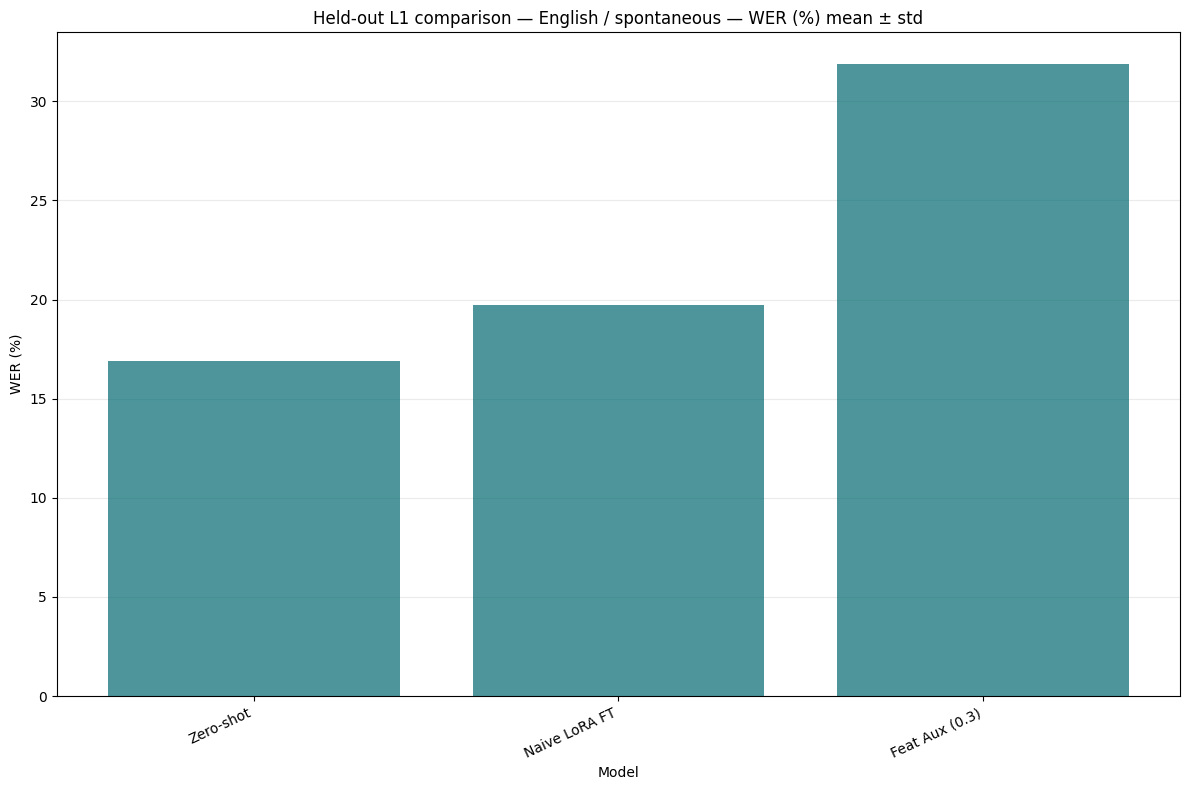

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

outdir = Path("output")
outdir.mkdir(exist_ok=True)

held_out_l1 = "English"
split = "spontaneous"
model_keys = [
    "baseline",
    "no_aux",
    # "no_aux_heldout_chinese",
    "feat_aux",
    # "feat_aux_heldout_chinese",
    "feat_aux0p3",

]

rows = []
for key in model_keys:
    if key not in results or split not in results[key]:
        continue

    df = results[key][split].copy()
    if "l1" not in df.columns:
        continue

    df = df[df["l1"] == held_out_l1]
    if len(df) == 0:
        continue

    row = {
        "model_key": key,
        "model": MODEL_KEYS.get(key, key),
        "n_utts": len(df),
        "n_speakers": df["speaker"].nunique() if "speaker" in df.columns else None,
        "wer_mean": corpus_wer(df) * 100,
    }

    if "utt_per" in df.columns:
        row["per_mean"] = df["utt_per"].mean()
        row["per_std"] = df["utt_per"].std()

    rows.append(row)

heldout_cmp = pd.DataFrame(rows).reset_index(drop=True)
heldout_cmp.to_csv(outdir / "heldout_l1_comparison.csv", index=False)

plot_df = heldout_cmp.copy()
plot_df["label"] = plot_df["model"] if "model" in plot_df.columns else plot_df["model_key"]

metrics = [("wer_mean", "WER (%)", "#01696f")]
# if "per_mean" in plot_df.columns and plot_df["per_mean"].notna().any():
#     metrics.append(("per_mean", "per_std", "PER", "#0b5177"))

fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 8 * len(metrics)), sharex=True)
if len(metrics) == 1:
    axes = [axes]

x = range(len(plot_df))
for ax, (mean_col, title, color) in zip(axes, metrics):
    means = plot_df[mean_col].to_numpy()
    ax.bar(x, means, color=color, alpha=0.7, capsize=5)
    ax.set_ylabel(title)
    ax.set_title(f"Held-out L1 comparison — {held_out_l1} / {split} — {title} mean ± std")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(plot_df["label"], rotation=25, ha="right")
axes[-1].set_xlabel("Model")

fig.tight_layout()
fig.savefig(outdir / "heldout_l1_points_whiskers.png", dpi=200, bbox_inches="tight")
fig.show()
print(outdir / "heldout_l1_comparison.csv")
print(outdir / "heldout_l1_points_whiskers.png")

fmt = {
    c: "{:.3f}"
    for c in heldout_cmp.columns
    if c.startswith(("wer_", "per_"))
}


display(
    heldout_cmp.style
        .format(fmt)
        .set_caption(f"Held-out L1 comparison — {held_out_l1} / {split}")
)

In [ ]:
import numpy as np
import pandas as pd

def align_for_sigtest(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    group_value: str | None = None,
    group_col: str = "l1",
    metric_col: str = "utt_wer",
) -> pd.DataFrame:
    a = df_a.copy()
    b = df_b.copy()

    if group_value is not None:
        a = a[a[group_col] == group_value].copy()
        b = b[b[group_col] == group_value].copy()

    cols_a = ["utterance_id", group_col, metric_col]
    cols_b = ["utterance_id", group_col, metric_col]

    merged = (
        a[cols_a]
        .rename(columns={metric_col: "score_a", group_col: f"{group_col}_a"})
        .merge(
            b[cols_b].rename(columns={metric_col: "score_b", group_col: f"{group_col}_b"}),
            on="utterance_id",
            how="inner",
        )
    )

    if group_value is None and f"{group_col}_a" in merged.columns:
        merged[group_col] = merged[f"{group_col}_a"]

    merged = merged.dropna(subset=["score_a", "score_b"]).copy()
    merged["diff"] = merged["score_a"] - merged["score_b"]   # positive => model B better
    return merged